<a href="https://colab.research.google.com/github/srishti-bs/Statistical-Foundations-of-Data-Science/blob/main/DistributionofEstimators.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OLS Estimate: [1.17628637 2.96665735]
Alternative Estimate: [1.76442956 4.44998603]
Variance of OLS estimator: 0.004591815835821002
Variance of Alternative estimator: 0.010331585630597257


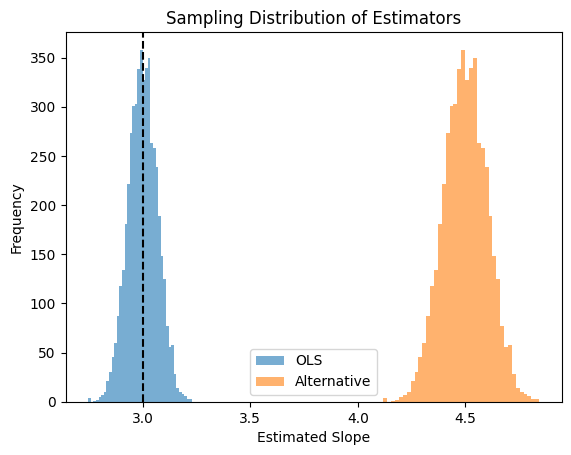

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Set parameters np.random.seed(42)
n = 100
beta_true = np.array([1.0, 3.0])
sigma = 2.0

# Step 2: Design matrix
X = np.column_stack((np.ones(n), np.linspace(0, 10, n)))

# Step 3: Generate response
eps = np.random.normal(0, sigma, n)
y = X @ beta_true + eps

# Step 4: OLS estimator
beta_ols = np.linalg.inv(X.T @ X) @ X.T @ y

# Step 5: Alternative linear unbiased estimator
A = np.eye(n) * 0.5
beta_alt = np.linalg.inv(X.T @ X) @ X.T @ (np.eye(n) + A) @ y

print("OLS Estimate:", beta_ols)
print("Alternative Estimate:", beta_alt)

# Step 6: Monte Carlo simulation
n_sim = 5000
ols_samples = []
alt_samples = []

for _ in range(n_sim):
  eps = np.random.normal(0, sigma, n)
  y_sim = X @ beta_true + eps
  beta_ols_sim = np.linalg.inv(X.T @ X) @ X.T @ y_sim
  beta_alt_sim = np.linalg.inv(X.T @ X) @ X.T @ (np.eye(n) + A) @ y_sim
  ols_samples.append(beta_ols_sim[1])
  alt_samples.append(beta_alt_sim[1])

# Step 7: Variance comparison
print("Variance of OLS estimator:", np.var(ols_samples))
print("Variance of Alternative estimator:", np.var(alt_samples))

# Step 8: Visualization
plt.hist(ols_samples, bins=40, alpha=0.6, label="OLS")
plt.hist(alt_samples, bins=40, alpha=0.6, label="Alternative")
plt.axvline(beta_true[1], color='black', linestyle='--')
plt.legend()
plt.title("Sampling Distribution of Estimators")
plt.xlabel("Estimated Slope")
plt.ylabel("Frequency")
plt.show()
